# [개념정리]

## 선형 회귀

*   선형모델: 입력 특성의 가중치 합+평향이라는 상수-> 예측값을 만듦
*   선형 회귀 모델 훈련 = 훈련세트에 가장 잘맞는 모델 파라미터 설정

  -> 평균제곱근오차(RMSE)를 최소화하는 theta를 찾아야함.

## 정규방정식

*   비용 함수를 최소화 하는 theta 값을 찾기 위한 해석 방법 -> 정규방정식
*  유사역행렬 X+를 계산하는 방법
  1) 알고리즘이 시그마를 먼저 구함
  2) 어떤 낮은 임계값보다 작은 모든 수를 0으로 바꿈
  3) 0이 아닌 모든 값을 역수로 치환
  4) 만들어진 행렬을 전치함
  -> 유사역행렬은 특이행렬이라도 항상 구할 수 있다.(정규방정식과 달리)

## 계산 복잡도
* 역행렬을 계산하는 것임
* 예측 계산 복잡도 : 샘플수와 특정수에 선형적인 관계를 가짐.

## 경사 하강법
* 비용 함수를 최소화하기 위해 반복해서 파라미터를 조정해나가는 것을 말함.
* theta를 무작위 초기화(임의의 값으로 시작해서)로 하여 한번에 조금씩 비용함수가 감소되는 방향으로 진행하여 점진적으로 향상시킴
* 주요 파라미터: 학습률(learing rate)
* if 학습률이 작음-> 반복을 많이 진행하여 시간이 오래걸림
* gloabl minimum vs. local minimum
* MSE 비용함수 : 지역최솟값이 없고 하나의 전역 최솟값만 있음 (why? 볼록 함수 이므로)
* **경사하강법을 사용할때는 반드시 모든 특성이 같으 스케일을 갖도록 만들어야함.**

## 배치 경사 하강법
* theta가 조금 변경될때 얼마나 바뀌는지 계산해야함.
* 매 스텝에서 훈련 데이터 전체를 사용함
* 속도: 느림
* 언제? 수십만개의 특성에서 선형회귀를 훈련시킬때 빠름
* 적절한 학습률을 찾으려면 그리드 탐색을 사용함
* 반복 횟수 지정 방법 : 반복횟수를 아주 크게 지정하고 그레이디언트 벡터가 아주 작아지면 가능해짐.

## 확률적 경사 하강법
* 매 스텝에서 한개의 샘플을 무작위로 선택하고 그 하나의 샘플에 대한 그레이디언트를 계산함
* 속도: 빠름
* 언제? 매우 큰 훈련 세트도 훈련시킬 수 잇음 but 불안점함.
* learning schedule: 매 반복에서 학습률을 결정하는 함수를 말함.
* epoch : 반복횟수

##미니배치 경사 하강법
* 미니배치 : 임의의 작은 샘플 세트에 대한 그레이디언트를 계산함
* 장점: GPU를 사용해서 얻는 성능 향상, SGD보다 덜 불규칙하게 움직임.

## 다항 회귀
* 각 특성의 거듭제곱을 새로운 특성으로 추가하고, 이 확장된 특성을 포함한 데이터 셋에 선형 모델을 훈련시키는 것을 말함
* 사이킷럼의 PolynomialFeatures : 특성이 여러개일때 다항회귀는 이 특성 사이의 관계를 찾을 수 있음.

## 학습 곡선
* 모델의 일반화 성능을 추정하기 위해
  1) 교차검증을 사용함
  2) 학습 곡선을 살펴보는 것

    ->훈련 세트와 검증세트의 모델 성능을 훈련 세트 크기의 함수로 나타냄


* 과대접합의 특성: 두 곡선 사이에 공간이 있고, 훈련 데이터에서의 모델성능이 검증 데이터에서보다 훨씬 낫다는 뜻을 말함.
* if 과소적합시 -> 더 복잡한 모델을 사용하거나 더 나은 특성을 선택해야함
* if 과대적합시 -> 검증 오차가 훈련오차에 근접할때까지 더 많은 훈련 데이터를 추가하는 것을 말함.

* 편향/분산 트레이드오프: 모델의 복잡도가 커지면 통상적으로 분산이 늘어나고 편향을 줄어듭니다.









---

# [코드 필사]

In [19]:
import numpy as np

X=2*np.random.rand(100,1)
y=4+3*X+np.random.randn(100,1)

In [20]:
X_b=np.c_[np.ones((100,1)), X] #모든 샘플에 x0=1을 추가합니다
theta_best=np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [21]:
theta_best

array([[3.86185812],
       [2.98747128]])

In [22]:
X_new=np.array([[0],[2]])
X_new_b=np.c_[np.ones((2,1)), X_new] #모든 샘플에 x0=1을 추가합니다
y_predict=X_new_b.dot(theta_best)
y_predict

array([[3.86185812],
       [9.83680069]])

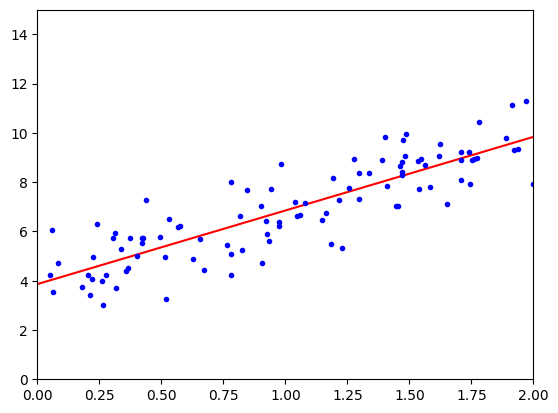

In [23]:
import matplotlib.pyplot as plt
plt.plot(X_new, y_predict, 'r-')
plt.plot(X,y, 'b.')
plt.axis([0,2,0,15])
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X,y)

LinearRegression()

In [25]:
lin_reg.intercept_, lin_reg.coef_

(array([3.86185812]), array([[2.98747128]]))

In [26]:
lin_reg.predict(X_new)

array([[3.86185812],
       [9.83680069]])

In [27]:
theta_best_svd, residuals, rank, x=np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.86185812],
       [2.98747128]])

In [28]:
np.linalg.pinv(X_b).dot(y)

array([[3.86185812],
       [2.98747128]])

In [29]:
#배치 경사 하강법
eta=0.1 #학습률
n_iterations=1000
m=100

theta=np.random.randn(2,1) #무작위 초기화

for iteration in range(n_iterations):
  gradients=2/m*X_b.T.dot(X_b.dot(theta)-y)
  theta=theta-eta*gradients

In [30]:
theta

array([[3.86185812],
       [2.98747128]])

In [31]:
# 확률적 경사 하강법
n_epochs=50
t0,t1=5,50 # 학습 스케줄 하이퍼파라미터

def learning_schedule(t):
  return t0/(t+t1)

theta= np.random.randn(2,1) # 무작위 초기화
#여기에서 randn은 가우시안 표준 정규 분포인 난수를 생성함.

for epoch in range(n_epochs):
  for i in range(m):
    random_index= np.random.randint(m)
    xi=X_b[random_index:random_index+1]
    yi=y[random_index:random_index+1]
    gradients=2*xi.T.dot(xi.dot(theta)-yi)
    eta=learning_schedule(epoch*m+i)
    theta=theta-eta*gradients

In [32]:
theta

array([[3.82081974],
       [2.96865847]])

In [34]:
from sklearn.linear_model import SGDRegressor
sgd_reg=SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, penalty=None)

In [35]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.87049918]), array([2.98921866]))

In [36]:
#다항회귀

n=100
X=6*np.random.rand(m,1)-3
y=0.5+X**2+X+2+np.random.randn(m,1)

In [40]:
from sklearn.preprocessing import PolynomialFeatures
poly_features=PolynomialFeatures(degree=2, include_bias=False)
X_poly=poly_features.fit_transform(X)

In [41]:
X[0]

array([0.59330588])

In [42]:
X_poly[0]

array([0.59330588, 0.35201187])

In [43]:
lin_reg=LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.61635562]), array([[1.01594422, 1.00258602]]))

In [44]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
  X_train, X_val, y_train, y_val=train_test_split(X,y,test_size=0.2)
  train_errors, val_errors=[],[]
  for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_predict=model.predict(X_train[:m])
    y_val_predict=model.predict(X_val)
    train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))
  plt.plot(np.sqrt(train_errors),'r-+', linewidth=2, label='훈련세트')
  plt.plot(np.sqrt(val_errors), 'b-', linewidth=3, label='검증세트')

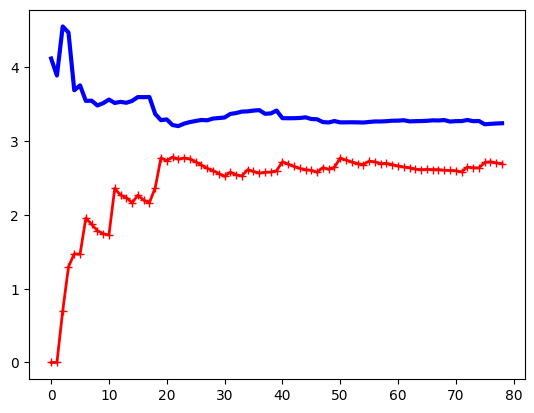

In [45]:
lin_reg=LinearRegression()
plot_learning_curves(lin_reg, X,y)

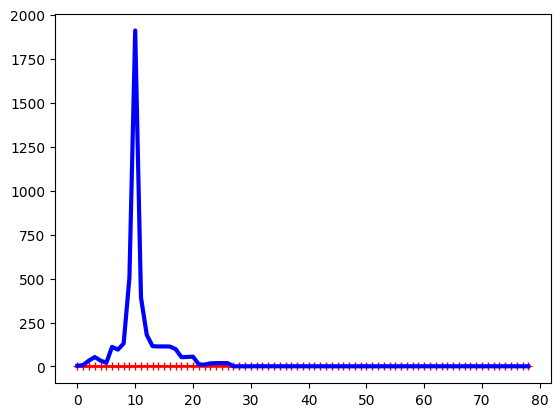

In [47]:
from sklearn.pipeline import Pipeline

polynomial_regression=Pipeline([
    ('poly_features', PolynomialFeatures(degree=10, include_bias=False)),
    ('lin_reg', LinearRegression()),
])

plot_learning_curves(polynomial_regression,X,y)